Graph: N=20, p=0.2, Edges=40


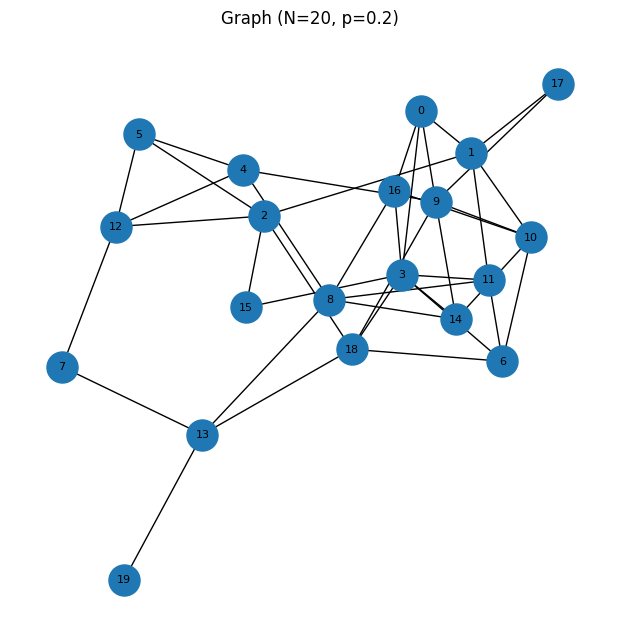

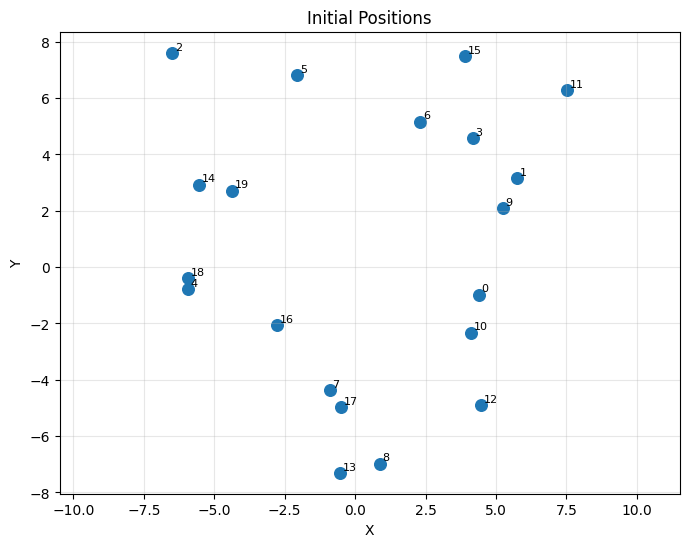

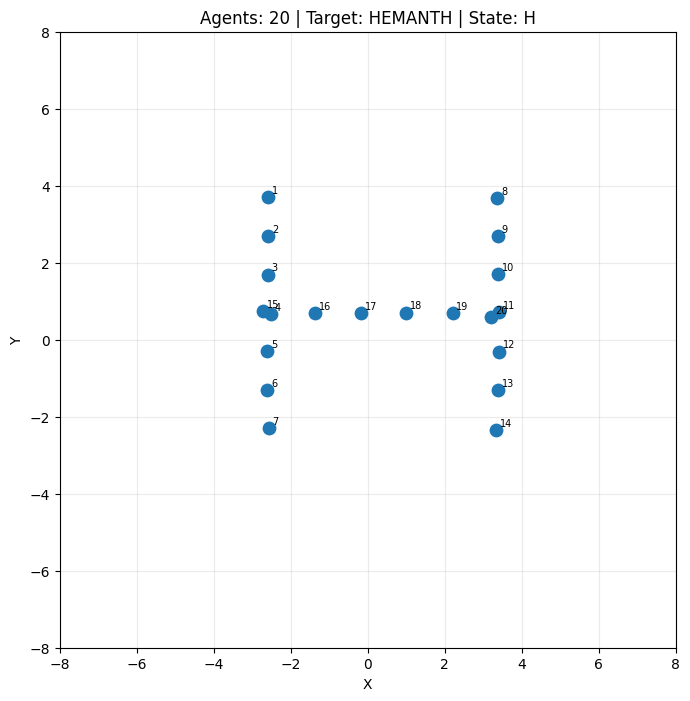

Saved Video as: hemanth.mp4


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
import networkx as nx

NAME = "HEMANTH"
N = 20
P = 0.20
SEED = 42
K = 2.5
DT = 0.04
INITIAL_HOLD = 60
MOVE_STEPS = 140
HOLD_STEPS = 25
K_REP = 0.05
R_SAFE = 0.4
MAX_REP = 3.0

LETTER_STROKES = {
    "H": [[(-1, 1), (-1, -1)], [(1, 1), (1, -1)], [(-1, 0), (1, 0)]],
    "E": [[(-1, 1), (-1, -1)], [(-1, 1), (1, 1)], [(-1, 0), (0.7, 0)], [(-1, -1), (1, -1)]],
    "M": [[(-1, -1), (-1, 1), (0, 0), (1, 1), (1, -1)]],
    "A": [[(-1, -1), (0, 1), (1, -1)], [(-0.55, 0), (0.55, 0)]],
    "N": [[(-1, -1), (-1, 1), (1, -1), (1, 1)]],
    "T": [[(-1, 1), (1, 1)], [(0, 1), (0, -1)]]
}

def sample_polyline(points, n_points):
    points = np.asarray(points, dtype=float)
    if len(points) == 1:
        return np.repeat(points, n_points, axis=0)
    segments = points[1:] - points[:-1]
    lengths = np.linalg.norm(segments, axis=1)
    total_length = np.sum(lengths)
    if total_length == 0:
        return np.repeat(points[:1], n_points, axis=0)
    cumulative = np.concatenate(([0], np.cumsum(lengths)))
    distances = np.linspace(0, total_length, n_points)

    result = []
    for d in distances:
        idx = np.searchsorted(cumulative, d, side="right") - 1
        idx = min(max(idx, 0), len(segments) - 1)
        alpha = 0 if lengths[idx] == 0 else (d - cumulative[idx]) / lengths[idx]
        result.append(points[idx] + alpha * segments[idx])

    return np.array(result)

def generate_letter_formation(letter, n_agents):
    strokes = LETTER_STROKES[letter]
    lengths = [np.sum(np.linalg.norm(np.diff(np.array(s), axis=0), axis=1)) for s in strokes]
    proportions = np.array(lengths) / np.sum(lengths)
    counts = np.maximum(np.floor(proportions * n_agents).astype(int), 1)
    while np.sum(counts) < n_agents:
        counts[np.argmax(proportions - counts / n_agents)] += 1
    while np.sum(counts) > n_agents:
        valid = np.where(counts > 1)[0]
        idx = valid[np.argmax(counts[valid] - proportions[valid] * n_agents)]
        counts[idx] -= 1
    points = np.vstack([sample_polyline(s, c) for s, c in zip(strokes, counts)])
    points -= np.mean(points, axis=0)
    max_val = np.max(np.abs(points))
    if max_val > 0:
        points = (points / max_val) * 3.0
    return points

def main():
    rng = np.random.default_rng(SEED)
    graph = nx.erdos_renyi_graph(N, P, seed=SEED)
    attempt = 0
    while not nx.is_connected(graph):
        attempt += 1
        graph = nx.erdos_renyi_graph(N, P, seed=SEED + attempt)
    print(f"Graph: N={N}, p={P}, Edges={graph.number_of_edges()}")

    Adj = nx.to_numpy_array(graph)
    Degree = np.diag(np.sum(Adj, axis=1))
    L = Degree - Adj

    positions = rng.uniform(-8, 8, size=(N, 2))
    centroid = np.mean(positions, axis=0)

    letters = list(NAME)
    formations = {}
    for letter in letters:
        target = generate_letter_formation(letter, N)
        target += centroid
        formations[letter] = target

    simulation = []
    letter_history = []
    current_pos = positions.copy()

    for _ in range(INITIAL_HOLD):
        simulation.append(current_pos.copy())
        letter_history.append("START")

    for letter in letters:
        target_pos = formations[letter]

        for _ in range(MOVE_STEPS):
            error = current_pos - target_pos
            attractive = -K * (L @ error)
            repulsive = np.zeros_like(current_pos)
            for i in range(N):
                for j in range(N):
                    if i == j:
                        continue
                    diff = current_pos[i] - current_pos[j]
                    dist = np.linalg.norm(diff)
                    if 0 < dist < R_SAFE:
                        magnitude = K_REP * (1.0/dist - 1.0/R_SAFE) * (1.0 / (dist**2))
                        repulsive[i] += magnitude * diff
            repulsive = np.clip(repulsive, -MAX_REP, MAX_REP)
            current_pos += DT * (attractive + repulsive)
            simulation.append(current_pos.copy())
            letter_history.append(letter)
        for _ in range(HOLD_STEPS):
            simulation.append(current_pos.copy())
            letter_history.append(letter)

    simulation = np.array(simulation)


    plt.figure(figsize=(6, 6))
    nx.draw(graph, nx.spring_layout(graph, seed=SEED),
            with_labels=True, node_size=500, font_size=8)
    plt.title(f"Graph (N={N}, p={P})")
    plt.show()

    plt.figure(figsize=(8, 6))
    plt.scatter(positions[:, 0], positions[:, 1], s=70)
    for i in range(N):
        plt.text(positions[i, 0] + 0.1, positions[i, 1] + 0.1, str(i), fontsize=8)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title("Initial Positions")
    plt.grid(True, alpha=0.3)
    plt.axis("equal")
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 8))
    scatter = ax.scatter(simulation[0, :, 0], simulation[0, :, 1], s=80)
    agent_labels = [ax.text(simulation[0, i, 0] + 0.1, simulation[0, i, 1] + 0.1, str(i + 1), fontsize=7)
                    for i in range(N)]
    ax.set(xlim=(-8, 8), ylim=(-8, 8), xlabel="X", ylabel="Y", aspect="equal")
    ax.grid(True, alpha=0.25)
    title_text = ax.set_title(f"Forming {NAME}")

    def update(frame):
        current = simulation[frame]
        scatter.set_offsets(current)

        for i, label in enumerate(agent_labels):
            label.set_position((current[i, 0] + 0.1, current[i, 1] + 0.1))

        current_letter = letter_history[frame]
        title_text.set_text(f"Agents: {N} | Target: {NAME} | State: {current_letter}")

        return [scatter, title_text] + agent_labels

    anim = FuncAnimation(fig, update, frames=len(simulation), interval=35, blit=False)
    vid_name = f"{NAME.lower()}.mp4"
    anim.save(vid_name, writer=FFMpegWriter(fps=30, bitrate=2500), dpi=150)
    plt.show()
    print(f"Saved Video as: {vid_name}")

if __name__ == "__main__":
    main()